# Applying Priors in the estimates

In this notebook, I demonstrate how the prior can be included in the Bayesian Framework. 

This is used in the recent work by L. Zallio+2026.

Script below prepared by D. Deng and L. Zallio.

In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# if you do not want to install ysoisochrone to your system PATH
# you can also use the following script to temporarily add the package to your PATH
# """
# github_dir = '/Users/dingshandeng/github/ysoisochrone/'
# sys.path.append(os.path.join(github_dir))
# """

import ysoisochrone

In [ ]:
# Set up a DataFrame in Python script
# For this target Sz71, values are from Alcala+2017, 
# and corrected later with the Gaia DR3 distance in Manara+2023
df_prop = pd.DataFrame({
    'Source': ['Sz71'], 
    'Teff[K]': np.array([3632.0]),
    'e_Teff[K]': np.array([167.0]),
    'Luminosity[Lsun]': np.array([0.327]),
    'e_Luminosity[Lsun]': np.array([0.1420])
})

## For the case assuming ages

In [ ]:
# 1) No prior (flat in log-mass): same as before
ysoisochrone.bayesian.derive_stellar_mass_assuming_age(df_prop, assumed_age=1e6)

array([[-0.4 , -0.51, -0.31]])

In [ ]:
# 2) Gaussian prior in log-mass (center 0.0 dex = 1 Msun, sigma 0.2 dex)
prior_mass = lambda logm: np.exp(-0.5*((logm - 0.0)/0.2)**2)
ysoisochrone.bayesian.derive_stellar_mass_assuming_age(df_prop, assumed_age=1e6, prior_mass=prior_mass)

array([[-0.32, -0.41, -0.24]])

## For the case that I have the mass as prior

  0%|          | 0/1 [00:00<?, ?it/s]

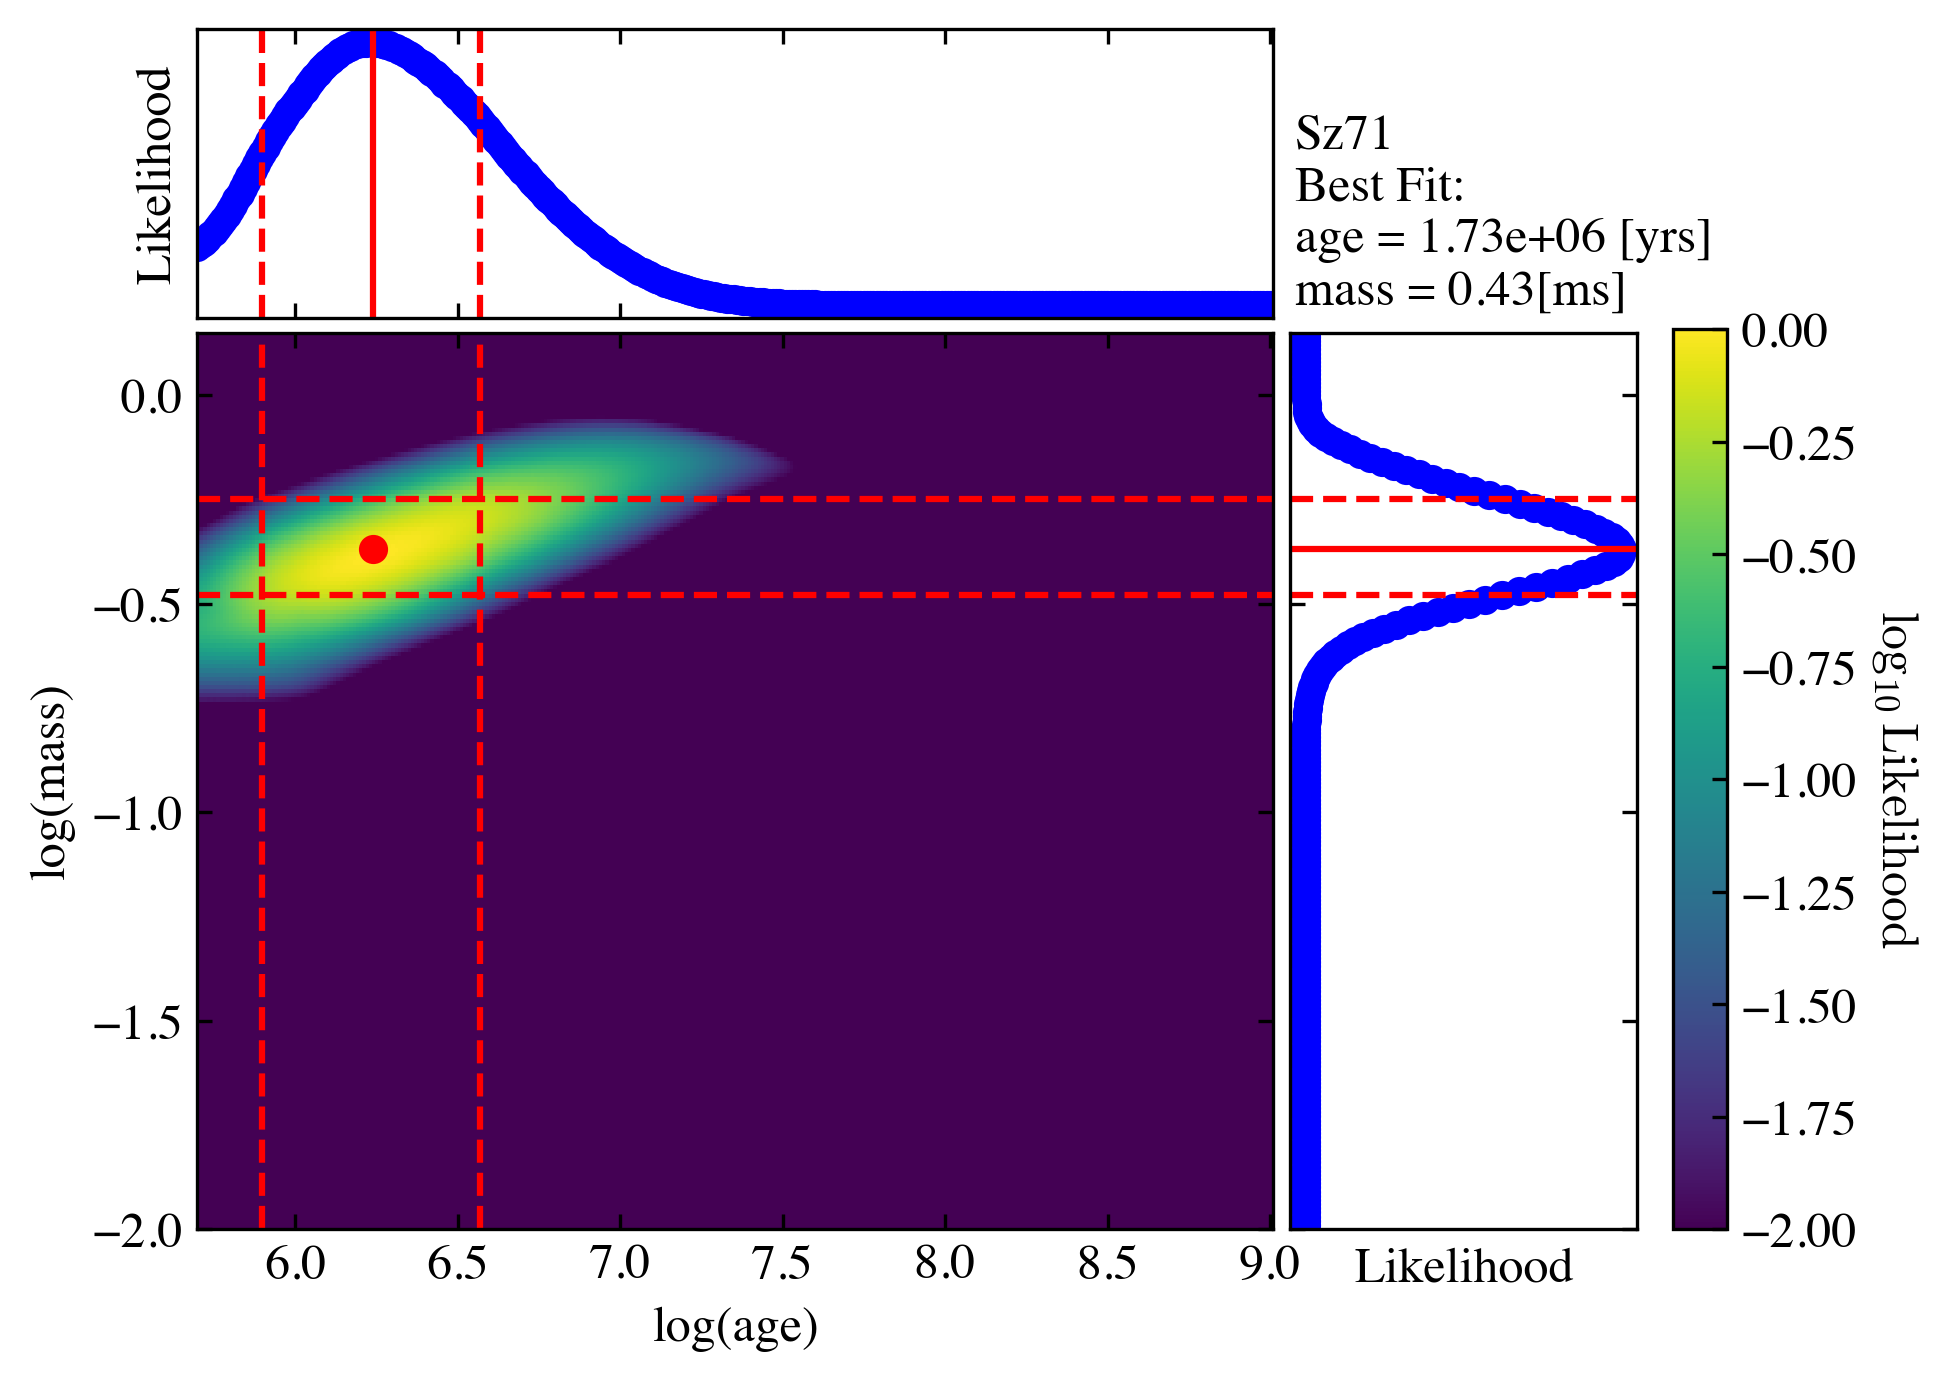

100%|██████████| 1/1 [00:00<00:00,  1.79it/s]


In [ ]:
# 1) without any prior
best_logmass_output, best_logage_output, lmass_all, lage_all, flag_all =\
    ysoisochrone.bayesian.derive_stellar_mass_age(
        df_prop,
        model='Baraffe_n_Feiden',
        # model='Baraffe2015',
        plot=True,
        )

  0%|          | 0/1 [00:00<?, ?it/s]

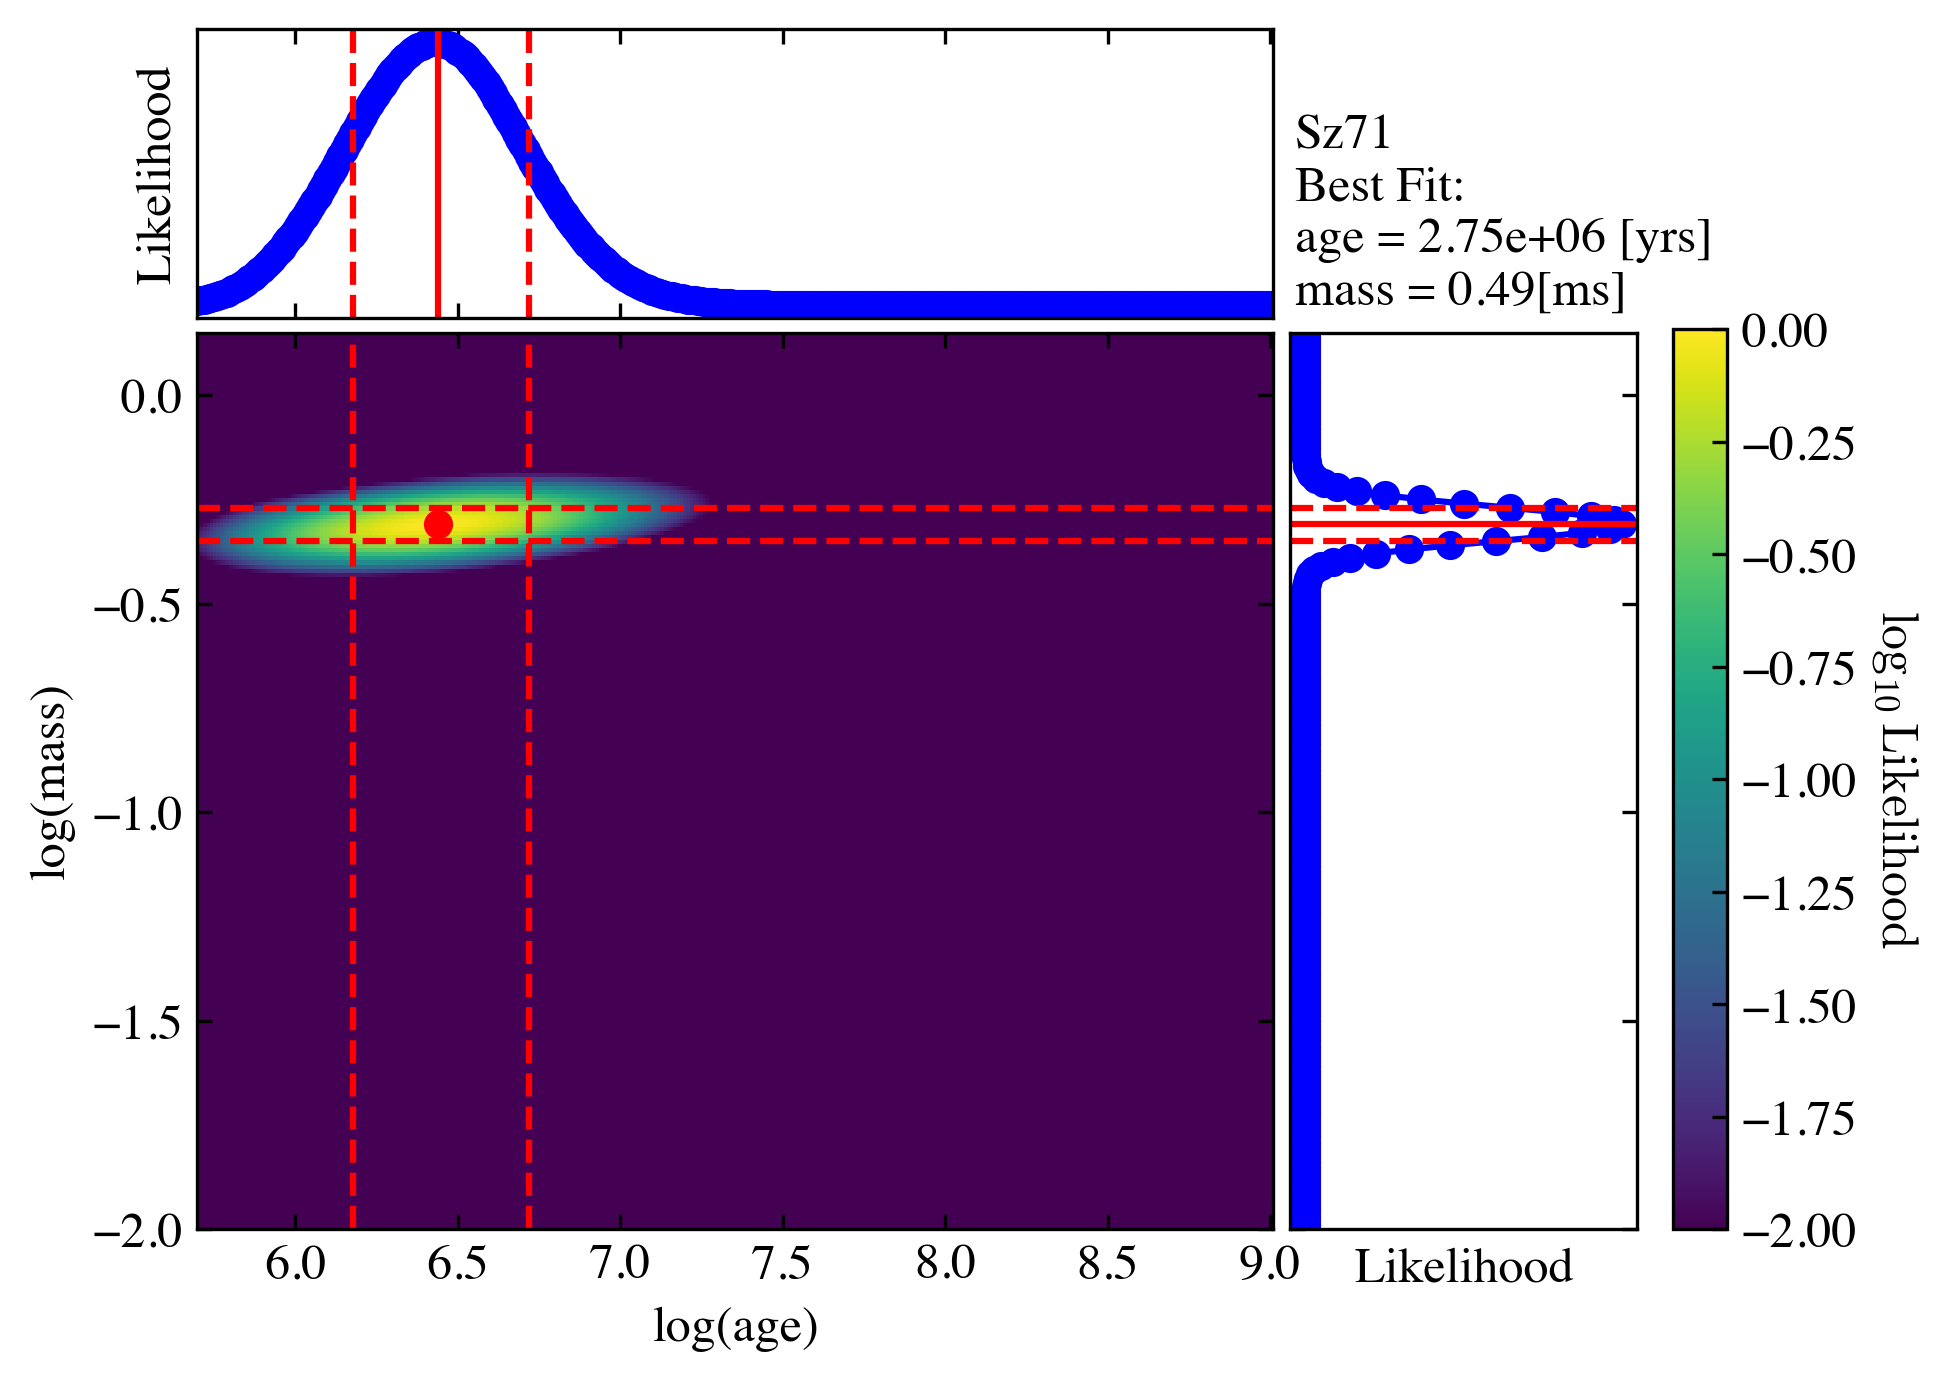

100%|██████████| 1/1 [00:00<00:00,  4.27it/s]


In [ ]:
# 2) A Gaussian Prior
# Gaussian prior in *linear* mass (Msun), μ = 0.5 Msun, σ = 0.1 Msun
mu_logm = np.log10(0.5)            # log10(0.5 Msun)
sigma_logm = 0.1 / (np.log(10))    # ≈ 0.0434 dex for 10% at 1 Msun
prior_mass = lambda logm: np.exp(-0.5*((logm - mu_logm)/sigma_logm)**2)

# Pass this prior mass into the routine
best_logmass_output, best_logage_output, lmass_all, lage_all, flag_all =\
    ysoisochrone.bayesian.derive_stellar_mass_age(
        df_prop,
        model='Baraffe_n_Feiden',
        plot=True,
        prior_mass=prior_mass)

Other priors

for example, if the age prior is also used

  0%|          | 0/1 [00:00<?, ?it/s]

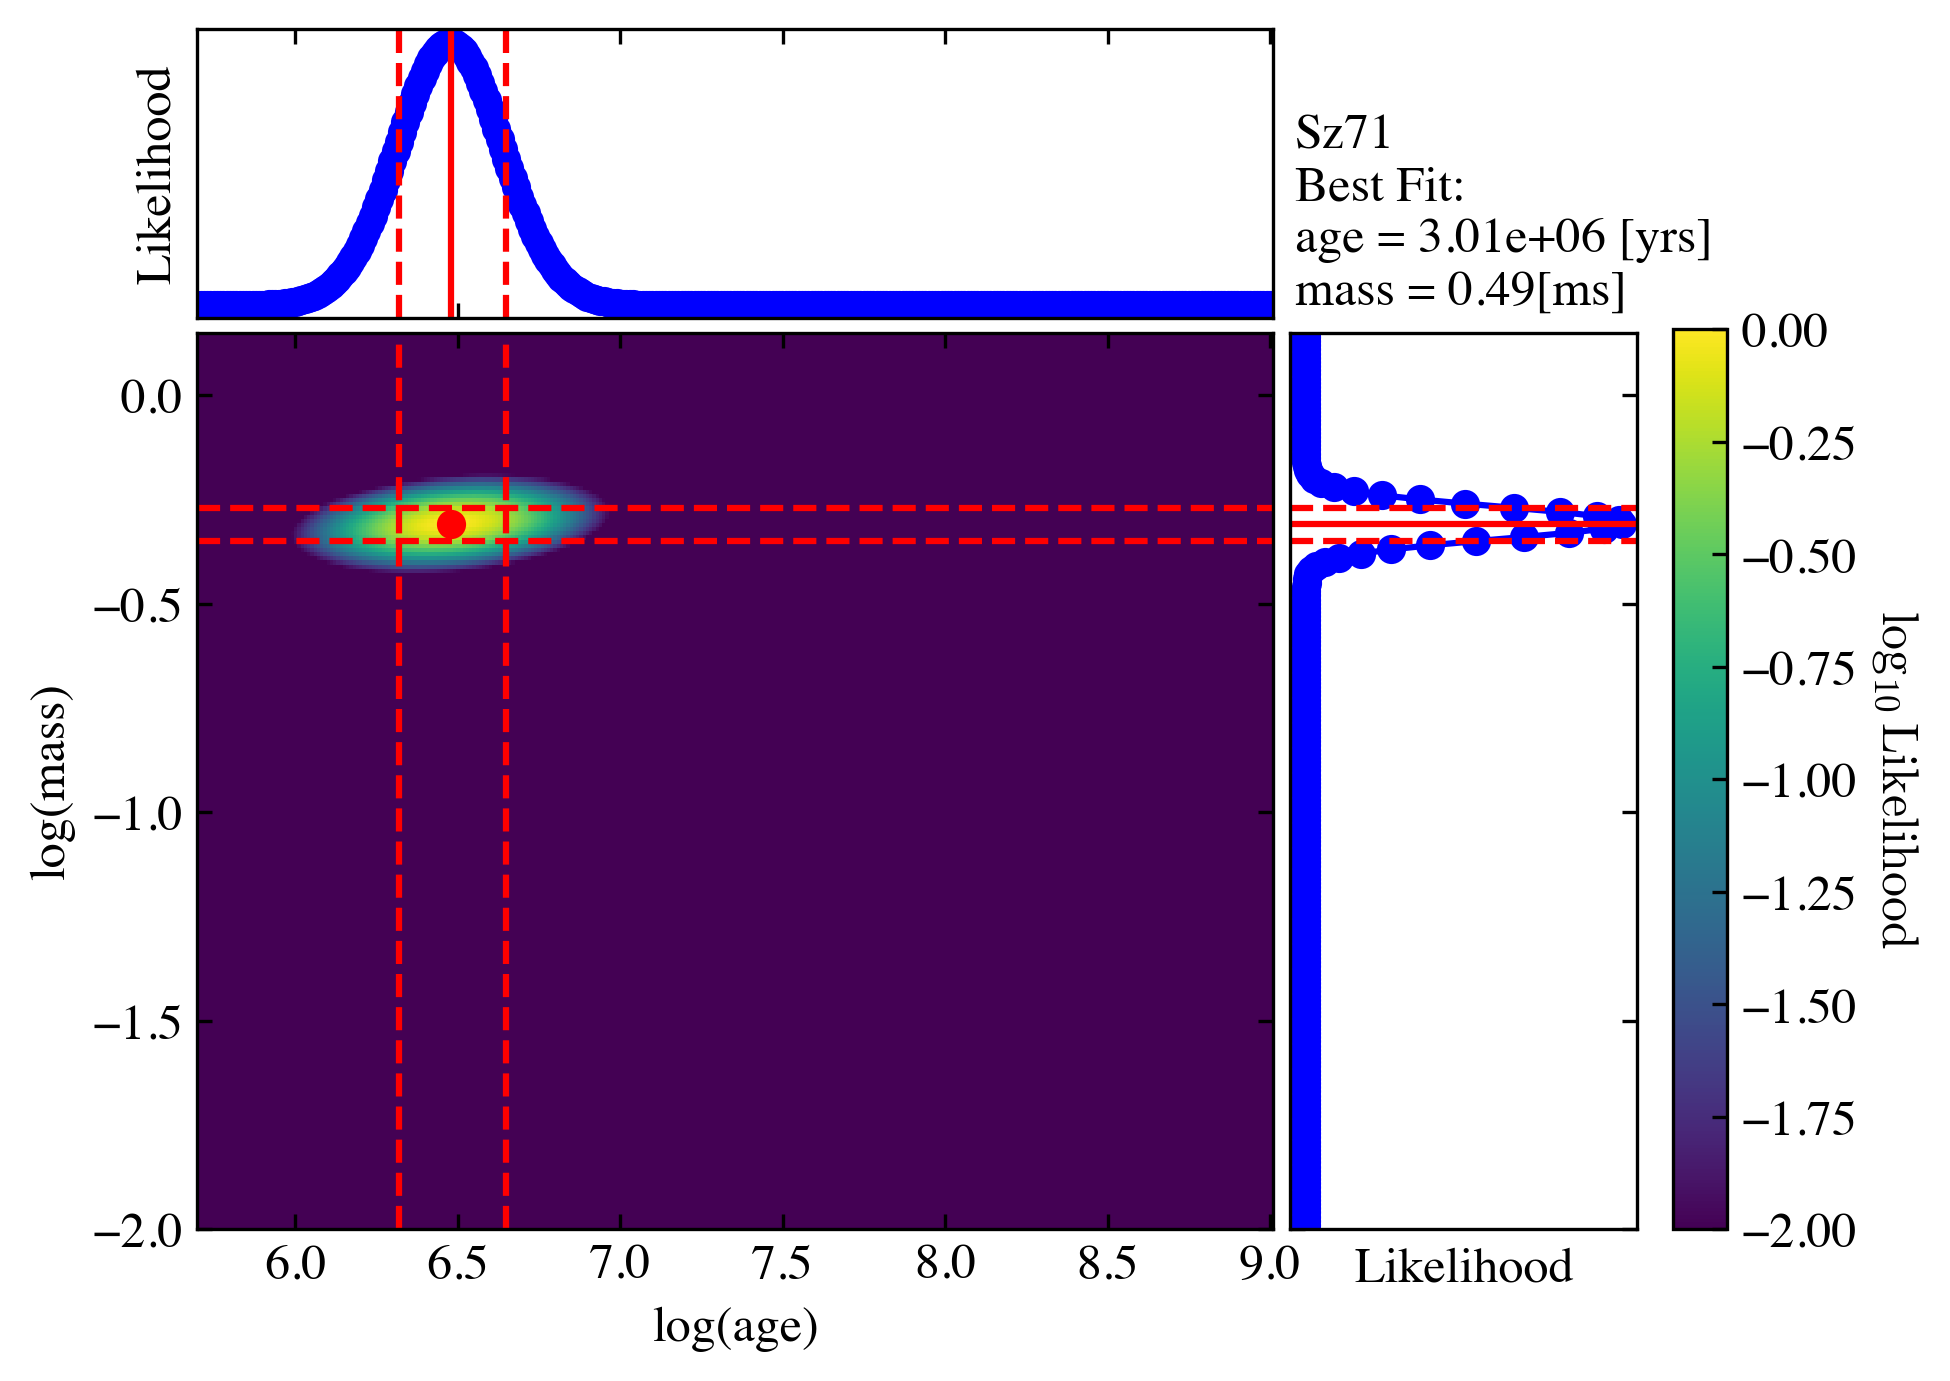

100%|██████████| 1/1 [00:00<00:00,  4.16it/s]


In [ ]:
# 3) together with age_prior, you can also only use age_prior
# Gaussian prior in *linear* mass (Msun), μ = 0.5 Msun, σ = 0.1 Msun
mu_logm = np.log10(0.5)            # log10(0.5 Msun)
sigma_logm = 0.1 / (np.log(10))    # ≈ 0.0434 dex for 10% at 1 Msun
prior_mass = lambda logm: np.exp(-0.5*((logm - mu_logm)/sigma_logm)**2)

# Gaussian prior on log(age/yr) centered at 6.5 with σ=0.2 dex:
mu_logage = 6.5
sigma_logage = 0.2
prior_age = lambda logage: np.exp(-0.5*((logage - mu_logage)/sigma_logage)**2)

# Pass this prior mass into the routine
best_logmass_output, best_logage_output, lmass_all, lage_all, flag_all =\
    ysoisochrone.bayesian.derive_stellar_mass_age(
        df_prop,
        model='Baraffe_n_Feiden',
        plot=True,
        prior_mass=prior_mass,
        prior_age =prior_age)

  0%|          | 0/1 [00:00<?, ?it/s]

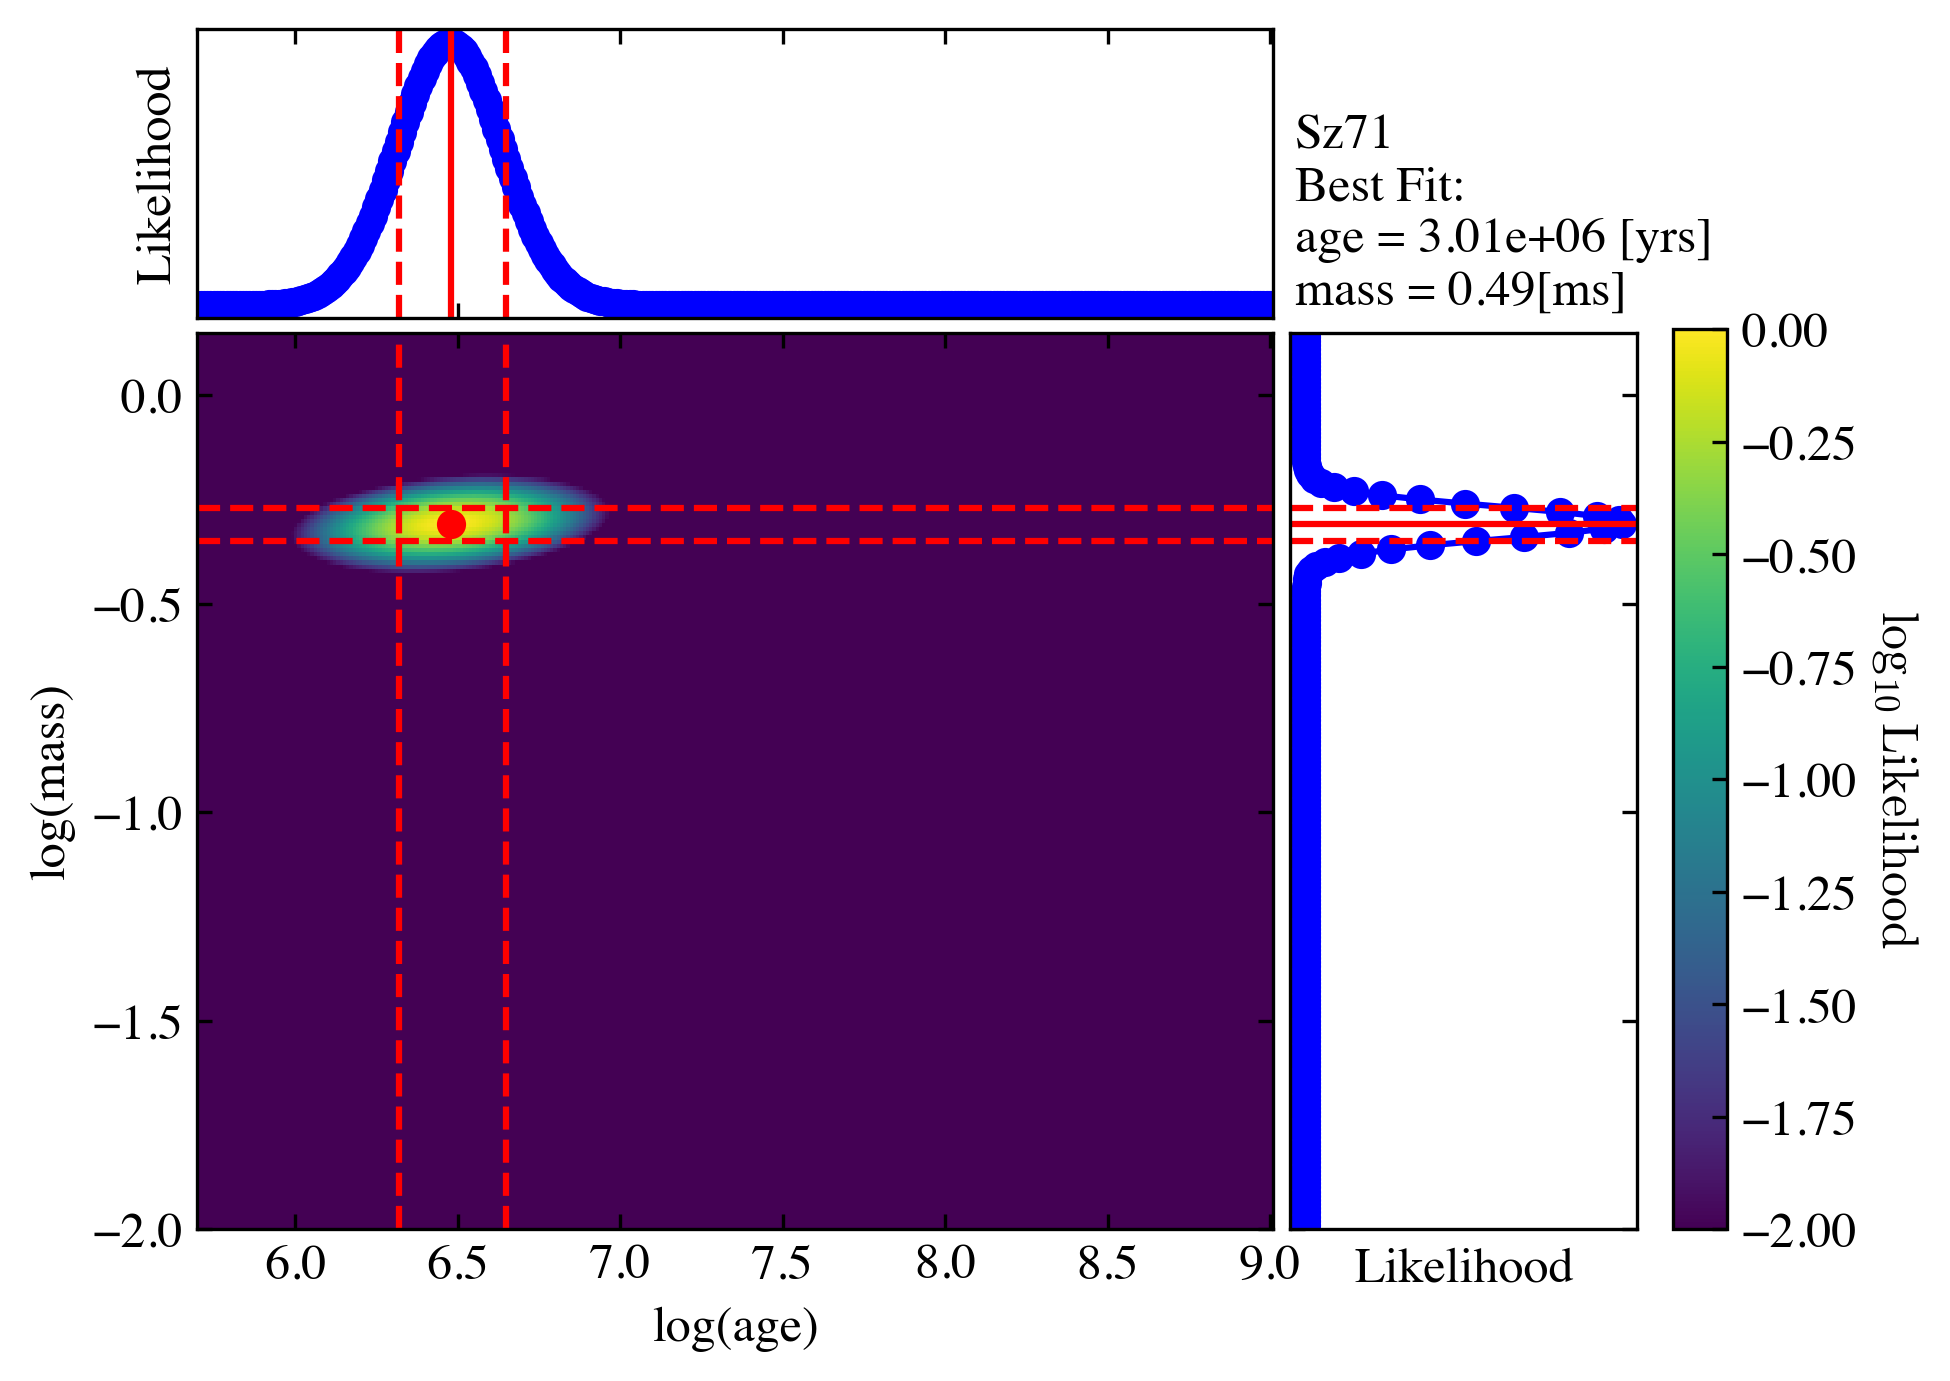

100%|██████████| 1/1 [00:00<00:00,  4.14it/s]


In [ ]:
# 4) define a joint prior as a callable
# if you use this option, DO NOT use prior_age or prior_mass

# This is just an example for the fun_joint_prior
# it can be any function that you defined as long as it is 
# a callable to (logage, logmass)
def func_joint_prior(logage, logmass):
    # shapes like the meshgrid (Na, Nm)
    mu_logm = np.log10(0.5)            # log10(0.5 Msun)
    sigma_logm = 0.1 / (np.log(10))    # ≈ 0.0434 dex for 10% at 1 Msun

    # Gaussian prior on log(age/yr) centered at 6.5 with σ=0.2 dex:
    mu_logage = 6.5
    sigma_logage = 0.2
    
    return np.exp(-0.5*((logmass-mu_logm)/sigma_logm)**2) * np.exp(-0.5*((logage-mu_logage)/sigma_logage)**2)

# Pass this prior mass into the routine
best_logmass_output, best_logage_output, lmass_all, lage_all, flag_all =\
    ysoisochrone.bayesian.derive_stellar_mass_age(
        df_prop,
        model='Baraffe_n_Feiden',
        plot=True,
        prior_joint=func_joint_prior
        )

# Test the function to add a 2D prior as an array

Here I demonstrate how the 2D prior can be used as an array

In [ ]:
# Set up a DataFrame in Python script
# For this target Sz71, values are from Alcala+2017, 
# and corrected later with the Gaia DR3 distance in Manara+2023
df_prop = pd.DataFrame({
    'Source': ['Sz71'], 
    'Teff[K]': np.array([3632.0]),
    'e_Teff[K]': np.array([167.0]),
    'Luminosity[Lsun]': np.array([0.327]),
    'e_Luminosity[Lsun]': np.array([0.1420])
})

  0%|          | 0/1 [00:00<?, ?it/s]

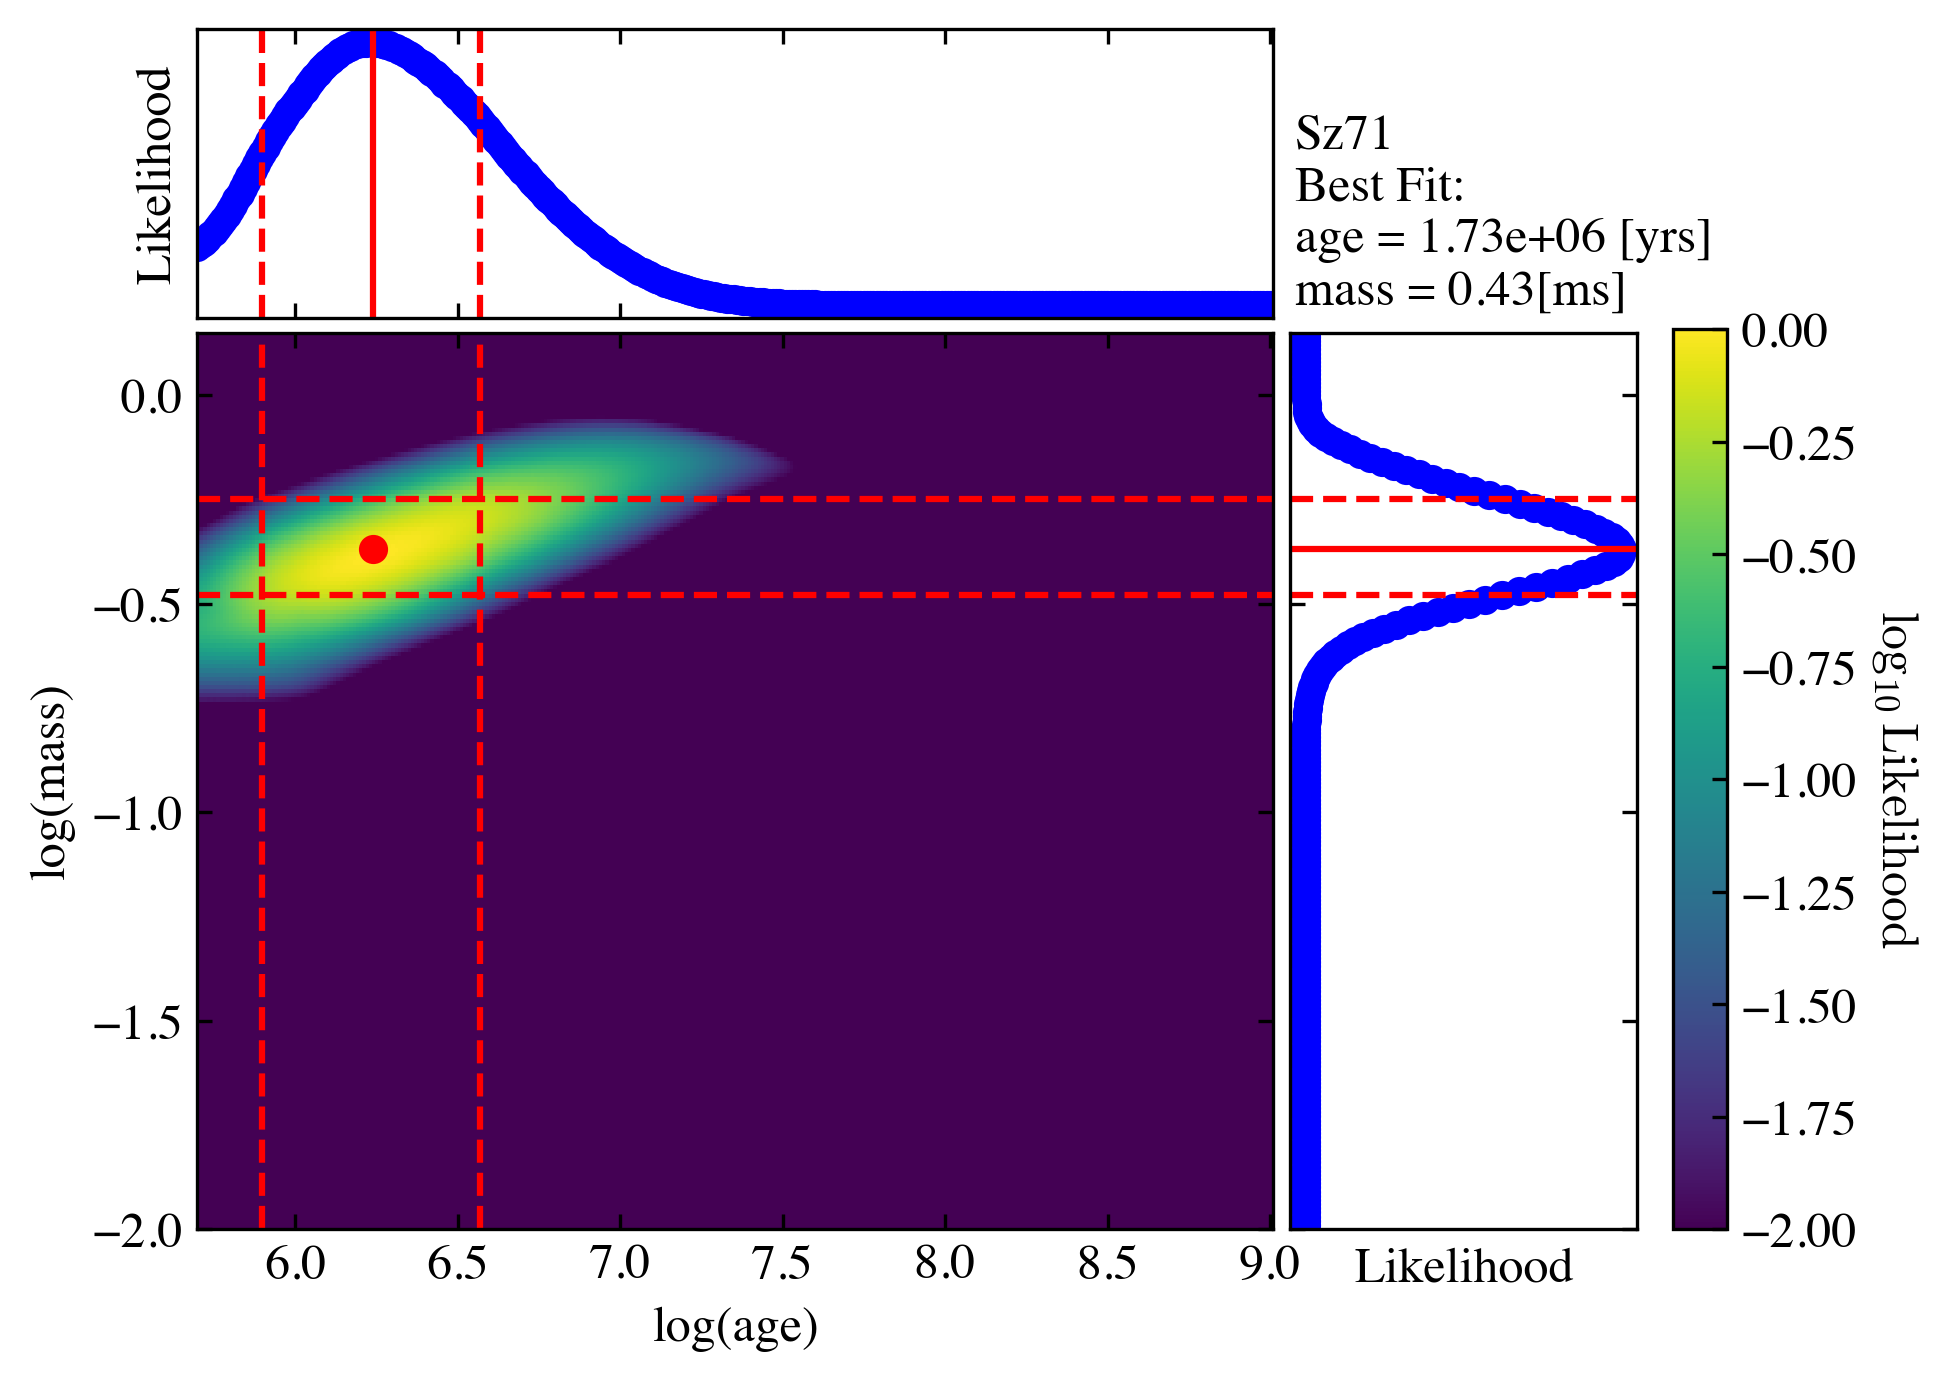

100%|██████████| 1/1 [00:00<00:00,  2.76it/s]


In [ ]:
# Call your Bayesian function without prior
best_logmass_output, best_logage_output, lmass_all, lage_all, flag_all = \
    ysoisochrone.bayesian.derive_stellar_mass_age(
        df_prop,
        model='Baraffe_n_Feiden',
        plot=True
    )

In [ ]:
from scipy.interpolate import RegularGridInterpolator

# --- A New function to wrap as an interpolating callable the code can evaluate on its mesh ---

def build_prior_callable_from_tabulated_grid(
    logage_grid, logmass_grid, pdf_grid,
    fill_value=0.0, bounds_error=False, normalize='maxone'
):
    """
    Wrap a tabulated 2D prior into an interpolating callable for the Bayesian engine.

    Purpose:
        Users may define a joint prior p(logAge, logMass) on their own (log10-age, log10-mass)
        grids. This helper converts that tabulated 2D array into a callable
        prior_joint(logage_mesh, logmass_mesh) that can be evaluated on the internal
        isochrone mesh used by derive_stellar_mass_age().

    Args:

        logage_grid: [array-like]
            1D monotonically increasing grid of log10(age/yr) where the prior is tabulated.
            Shape: (Na_user,)

        logmass_grid: [array-like]
            1D monotonically increasing grid of log10(M/Msun) where the prior is tabulated.
            Shape: (Nm_user,)

        pdf_grid: [array-like]
            2D array of prior values aligned with axes = (logage, logmass) using indexing='ij'.
            That is, pdf_grid[i, j] corresponds to (logage_grid[i], logmass_grid[j]).
            Shape: (Na_user, Nm_user).
            Values should be non-negative. Absolute normalization is optional and can be
            controlled via the `normalize` argument and/or downstream normalization.

        fill_value: [float, optional] Default: 0.0
            Value returned when evaluating outside the tabulated domain if bounds_error=False.
            Use 0.0 to set prior=0 out of bounds (recommended).

        bounds_error: [bool, optional] Default: False
            If True, raise an error when evaluation points fall outside the tabulated grid.
            If False, use `fill_value` for out-of-bounds points.

        normalize: [str, optional] Default: 'maxone'
            Optional pre-interpolation normalization of `pdf_grid` for numerical stability.
            Choices:
                - 'sum1'  : scale so the discrete sum over the user grid equals 1
                - 'maxone': scale so the maximum value equals 1
                - 'none'  : no renormalization (use values as provided)

    Returns:

        prior_joint: [callable]
            A function with signature:
                prior_joint(logage_mesh, logmass_mesh) -> 2D ndarray
            where `logage_mesh` and `logmass_mesh` are meshgrids (same shape) of log10(age/yr)
            and log10(M/Msun), typically produced inside derive_stellar_mass_age().
            The returned array matches the input mesh shape and is clipped to be non-negative.
"""

    logage_grid = np.asarray(logage_grid, float)
    logmass_grid = np.asarray(logmass_grid, float)
    pdf_grid = np.asarray(pdf_grid, float)

    if pdf_grid.shape != (logage_grid.size, logmass_grid.size):
        raise ValueError(
            f"pdf_grid shape {pdf_grid.shape} != {(logage_grid.size, logmass_grid.size)}"
        )

    # Optional extra normalization for stability before interpolation
    if normalize == 'sum1':
        s = pdf_grid.sum()
        if s > 0: pdf_grid = pdf_grid / s
    elif normalize == 'maxone':
        m = pdf_grid.max()
        if m > 0: pdf_grid = pdf_grid / m

    interp = RegularGridInterpolator(
        (logage_grid, logmass_grid),
        pdf_grid,
        bounds_error=bounds_error,
        fill_value=fill_value,
        method='linear'
    )

    def prior_joint(logage_mesh, logmass_mesh):
        pts = np.column_stack([logage_mesh.ravel(), logmass_mesh.ravel()])
        vals = interp(pts).reshape(logage_mesh.shape)
        return np.clip(vals, 0.0, np.inf)  # guard tiny negatives at edges
    
    return prior_joint

  0%|          | 0/1 [00:00<?, ?it/s]

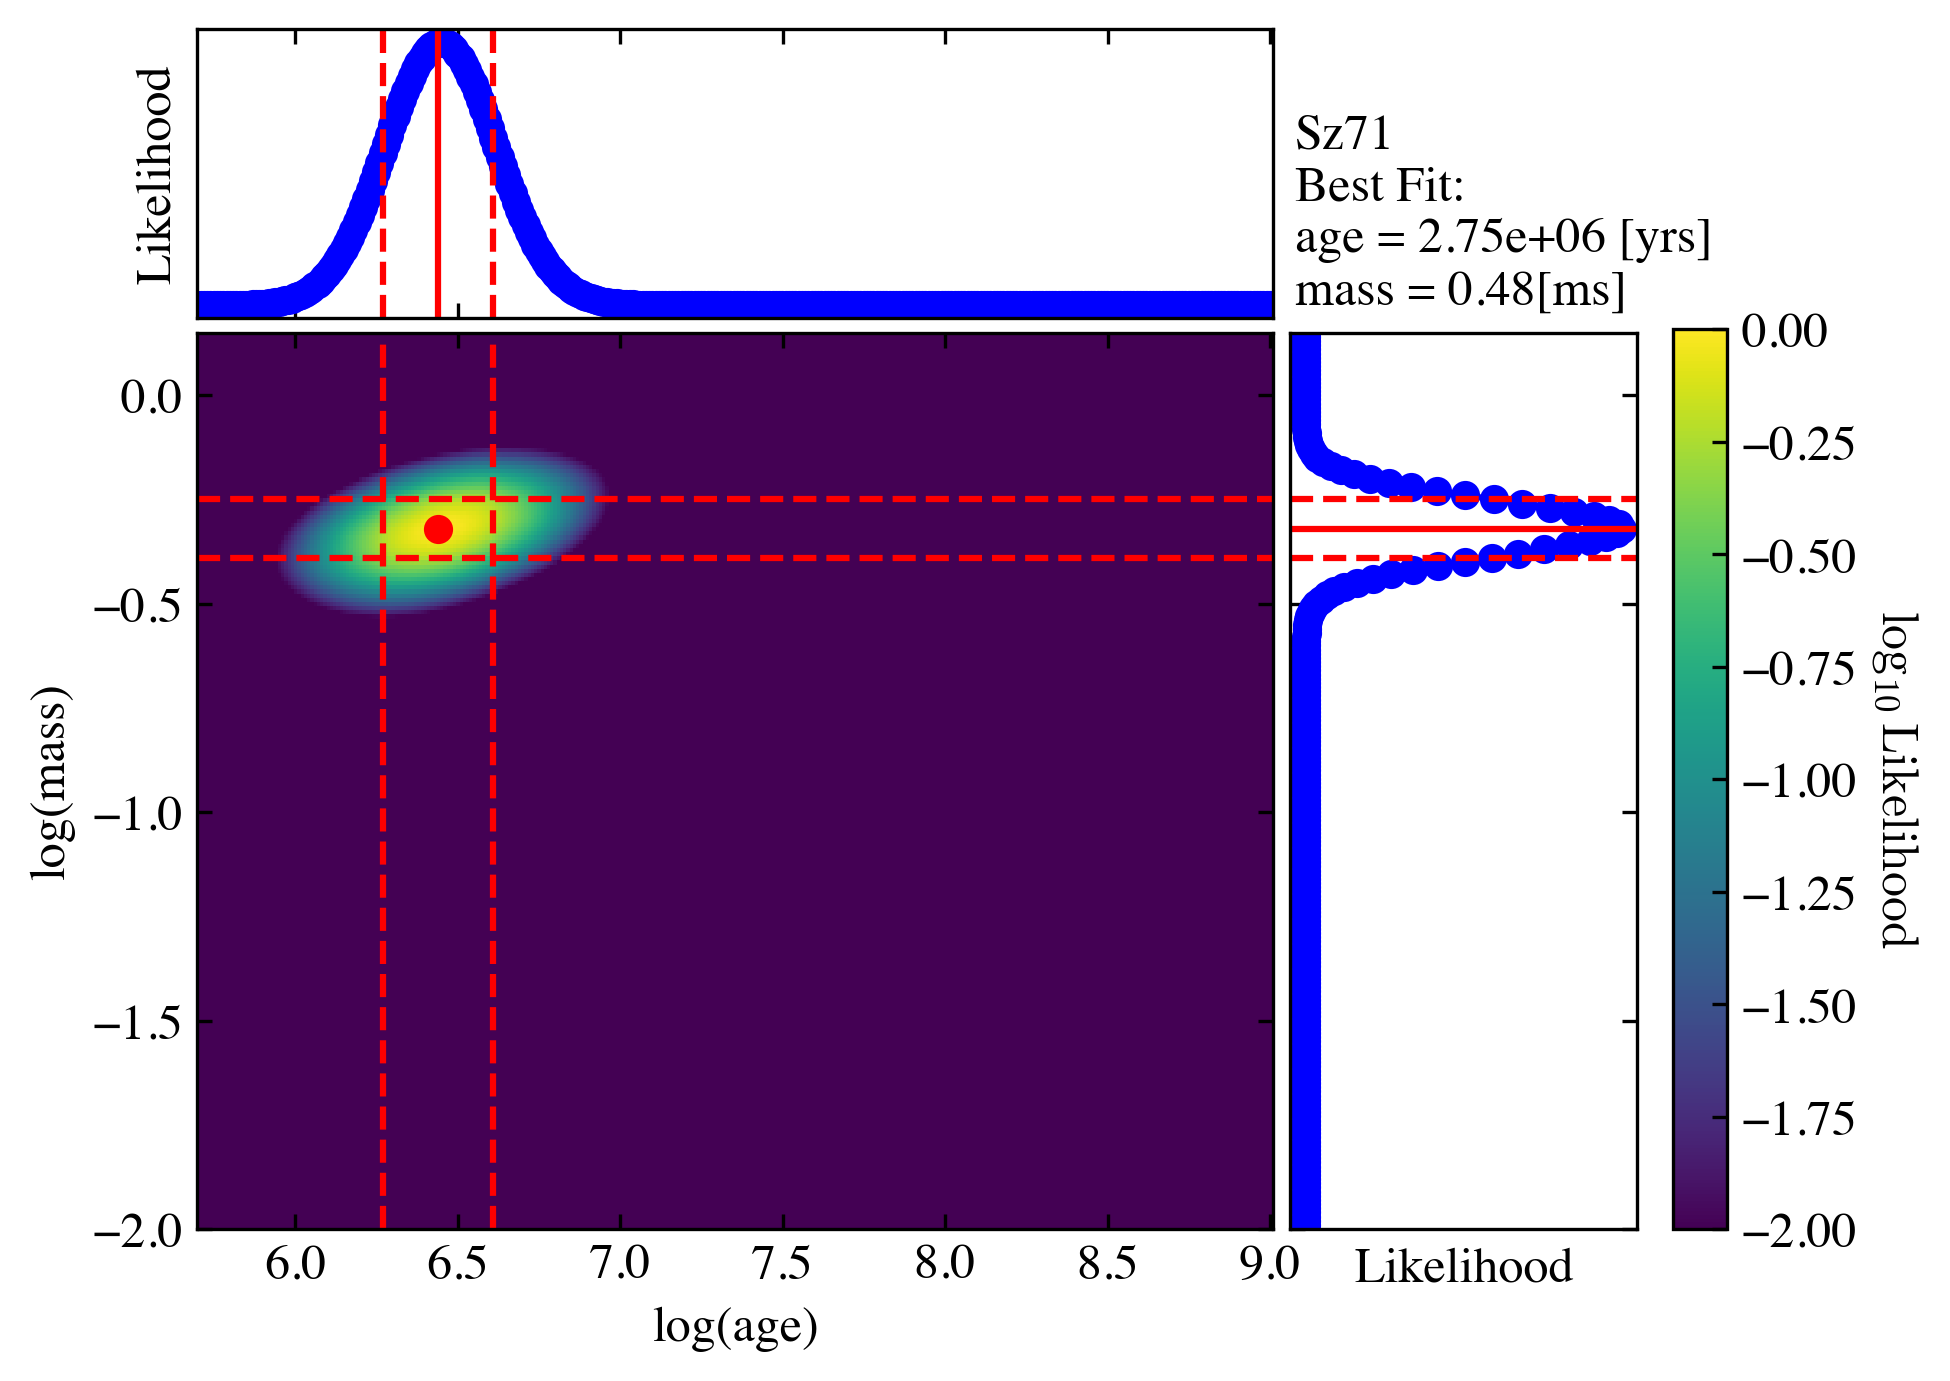

100%|██████████| 1/1 [00:00<00:00,  2.54it/s]


In [ ]:
"""code demo"""

# create a 2D gaussian as a demo 2D array

def gaussian2d_on_grid_demo(
    logage_grid, logmass_grid,
    mu_logage, mu_logmass,
    sigma_logage, sigma_logmass,
    rho=0.0,                    # correlation
    normalize='sum1'            # 'sum1' | 'maxone' | 'none'
):
    logage_grid = np.asarray(logage_grid, float)
    logmass_grid = np.asarray(logmass_grid, float)
    A, M = np.meshgrid(logage_grid, logmass_grid, indexing='ij')  # (Na, Nm)

    dx = (A - mu_logage) / sigma_logage
    dy = (M - mu_logmass) / sigma_logmass
    denom = 2.0 * (1.0 - rho**2)
    z = np.exp(-(dx**2 - 2.0*rho*dx*dy + dy**2) / denom)  # unnormalized

    if normalize.lower() == 'sum1':
        s = z.sum()
        if s > 0: z = z / s
    elif normalize.lower() == 'maxone':
        m = z.max()
        if m > 0: z = z / m
    return z  # shape (Na, Nm), axes=(logage, logmass)

# Demo: define YOUR tabulated grid (log10 years, log10 Msun)
logage_user  = np.linspace(5.5, 7.5, 121)                 # 0.3–31.6 Myr
logmass_user = np.linspace(np.log10(0.02), 0.5, 201)      # 0.02–~3.16 Msun

# Center/widths of the Gaussian prior in log10 units
prior_2dpdf_user_demo = gaussian2d_on_grid_demo(
    logage_grid=logage_user,
    logmass_grid=logmass_user,
    mu_logage=np.log10(3.0e6), # ~3.0 Myr
    mu_logmass=np.log10(0.5),# 0.5 Msun
    sigma_logage=0.20,       # 0.20 dex
    sigma_logmass=0.10,      # 0.10 dex
    rho=0.0,
    normalize='sum1'
)

# A New function to wrap as an interpolating callable the code can evaluate on its mesh
prior_joint = build_prior_callable_from_tabulated_grid(
    logage_grid=logage_user,
    logmass_grid=logmass_user,
    pdf_grid=prior_2dpdf_user_demo,
    fill_value=0.0,        # zero outside your tabulated domain
    bounds_error=False,
    normalize='maxone'     # fine; your pipeline renormalizes later anyway
)

# Call your Bayesian function with the interpolating prior
best_logmass_output, best_logage_output, lmass_all, lage_all, flag_all = \
    ysoisochrone.bayesian.derive_stellar_mass_age(
        df_prop,
        model='Baraffe_n_Feiden',
        plot=True,
        prior_joint=prior_joint       # <<== key: pass the callable
    )